## Previous steps
- Build TAVG = (Tmin+Tmax)*0.5 from GHCND data. 
( Tmin and Tmax data flagged by any of the following 'D|G|K|L|M|N|O|R|S|T|W|X|Z' are removed.)
- Compute AFI 
 AFI Season : '08-01' to '07-31'
 units : degree-days (°C-days)
 Conversion: AFI (°F-days) = AFI (°C-days) * 1.8
 Conversion: AFI (°C-hours) = AFI (°C-days) * 24
 Data Quality: 75% of days  during the defined AFI_season must report valid TMIN and TMAX, with no more than 10 consecutive days of missing data, for the annual AFI value to be calculated. Missing temperatures are linearly interpolated.
 Missing Data: Years for which AFI could not be calculated are indicated by blank entries in netcdf file.
 Engineering Information Type : Design General Values calculated according to referenced standards from which the 100-year return level (1% AEP) Design Parameter Values may be derived.
 Standards : Air Freezing Index calculated by this method is referenced in ASCE32-01 and ISO SO 13793:2001 standards.
 source : Global Historical Climatological Network Version 2. https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/.
 license : Creative Commons 1.0 Universal Public Domain Dedication (CC0-1.0) license.

 QFLAG

           Blank = did not fail any quality assurance check. 
           D     = failed duplicate check. 
           G     = failed gap check. 
           I     = failed internal consistency check. 
           K     = failed streak/frequent-value check. 
           L     = failed check on length of multiday period. 
           M     = failed megaconsistency check. 
           N     = failed naught check. 
           O     = failed climatological outlier check. 
           R     = failed lagged range check. 
           S     = failed spatial consistency check. 
           T     = failed temporal consistency check. 
           W     = temperature too warm for snow. 
           X     = failed bounds check. 
           Z     = flagged as a result of an official Datzilla
               investigation

In [41]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as mpltcolors
import cmaps
from xhistogram.xarray import histogram
import geopandas as gpd
from matplotlib import cm

# Alaska Air Freezing Index Analysis

## Overview

This notebook analyzes the Air Freezing Index (AFI) across Alaska weather stations using data from the Global Historical Climatological Network (GHCND). The analysis examines long-term trends and patterns in cumulative freezing degree-days.

### Key Objectives

1. **Load AFI Data**: Import pre-computed Air Freezing Index values for Alaska stations from 1920 onwards
2. **Identify Quality Stations**: Filter stations with at least 20 years of valid AFI data after 1979
3. **Visualize Trends**: Display time series for each station with geographic context
4. **Interpret Patterns**: Examine spatial and temporal variations in Alaska's freezing conditions

### Data Source

- **Dataset**: GHCND Air Freezing Index (AFI)
- **Region**: Alaska (50°N to 72°N, 185°E to 232°E)
- **Time Period**: 1920–2025
- **Quality Threshold**: Minimum 20 years of valid AFI after 1979

### AFI Definition

The Air Freezing Index is a measure of the cumulative freezing degree-days experienced during a season (August 1 – July 31), calculated in °C-days according to ASCE32-01 and ISO SO 13793:2001 standards.

In [42]:
from scipy.signal import find_peaks, argrelextrema

In [43]:
import warnings
warnings.filterwarnings('ignore')

In [44]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [45]:
lon_min=185;lon_max=232
lat_min=50;lat_max=72

## Step 1: Define Analysis Domain

### Geographic Bounds

Alaska domain is defined by longitude and latitude boundaries:

In [46]:
ifile='~/data/AFI/ghcnd_afi_AK.nc'
ds = xr.open_dataset(ifile)
afi = ds['afi']
nb79 = ds['nb79']
units='°C-days'

In [47]:
ifile='~/OneDrive - UCB-O365/RAPrototype/GHCND/US_stations_nc/GHCND_Tmin_Tmax_30yr_AK.nc'
dso = xr.open_dataset(ifile)

- **File**: `ghcnd_afi_AK.nc` - Contains AFI values (°C-days) and count of years with valid data (nb79)
- **Variables**: 
  - `afi` - Air Freezing Index time series for each station
  - `nb79` - Number of valid AFI years after 1979 

In [48]:
names = []
longitudes = []
latitudes = []
for ip in range(len(ds.station)):
    istation = ds.station[ip].data.item()
    ii = np.where(dso.station==istation)[0]
    names.append(dso.name.isel(station=ii).data.item().split(',')[0])
    longitudes.append(dso['longitude'].isel(station=ii).data.item())
    latitudes.append(dso['latitude'].isel(station=ii).data.item())

- **Purpose**: Provides station names and geographic coordinates for labeling

## Step 3: Extract Station Metadata

### Station Information

Merge metadata from the two datasets to obtain station names, latitudes, and longitudes for all AFI stations:

In [49]:
names = np.array(names)
longitudes = np.array(longitudes)
latitudes = np.array(latitudes)

In [50]:
proj=ccrs.PlateCarree()

- Extracts station names, removing any secondary location information
- Captures coordinates (latitude/longitude) for each station
- Enables linking AFI time series to geographic locations

## Step 4: Visualize AFI Time Series with Geographic Context

### Multi-Panel Time Series Visualization

The following code generates multi-page figures, each containing 10 stations with their complete 1920–2025 AFI records.

**Figure Layout:**
- **Main panels** (left): 10 separate time series plots, one per station
- **Inset map** (upper right): Geographic map showing locations of the 10 stations in Alaska
- **Data shown**: Complete AFI record from 1920–2025 for each station

**Selection Criteria:**
- Only stations with ≥ 20 years of valid AFI data after 1979 are included
- Stations presented in groups of 10 across multiple pages
- Each station is labeled with an index number (0–9) both on the plot and on the inset map
- Title shows: (index, station name, count of valid AFI years post-1979)

**Interpretation Guide:**
- **Y-axis**: Air Freezing Index in °C-days (higher values = more severe freezing)
- **X-axis**: Calendar year (1920–2025)
- **Markers**: Colored dots at annual AFI values for each station
- **Inset map**: Shows spatial distribution of the 10 stations across Alaska

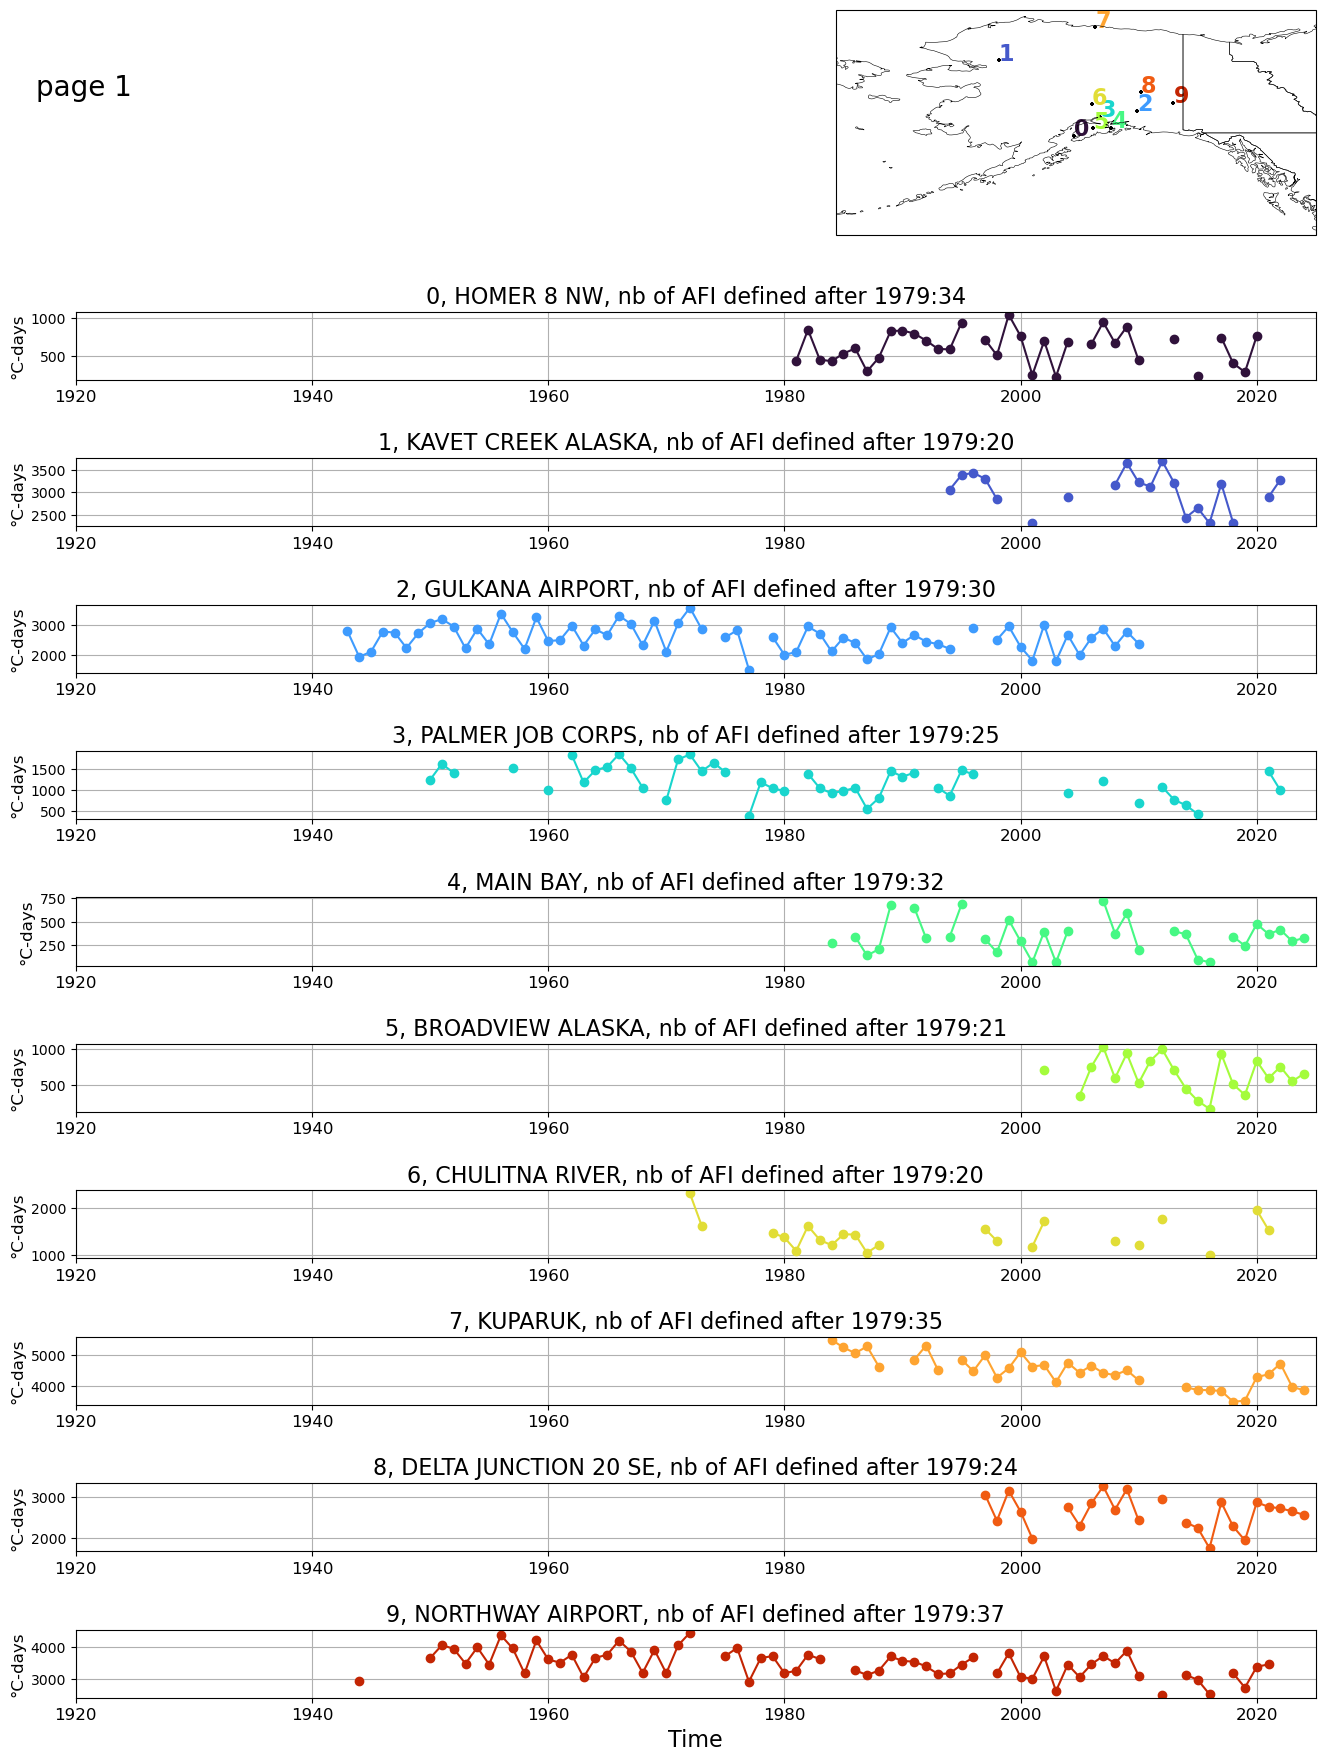

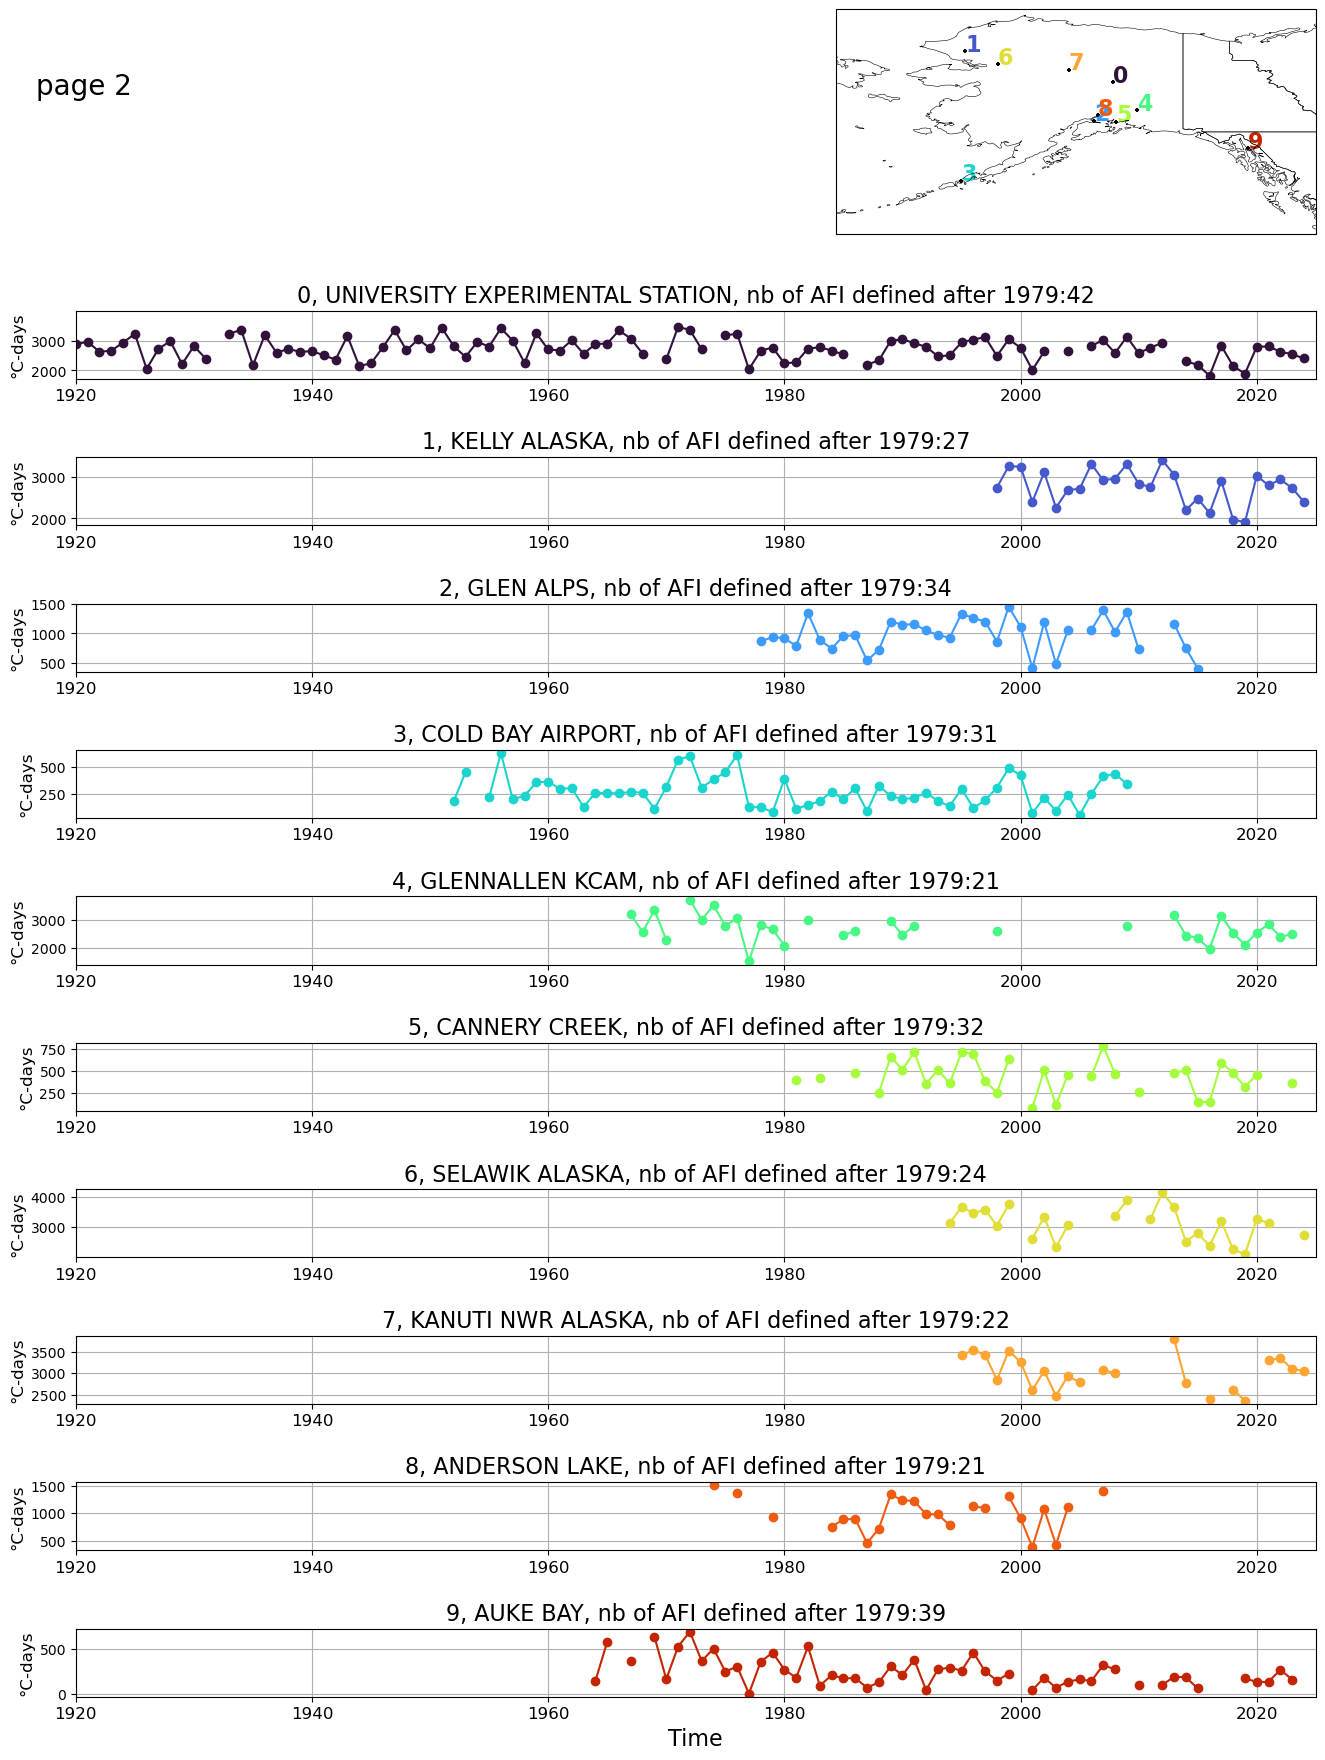

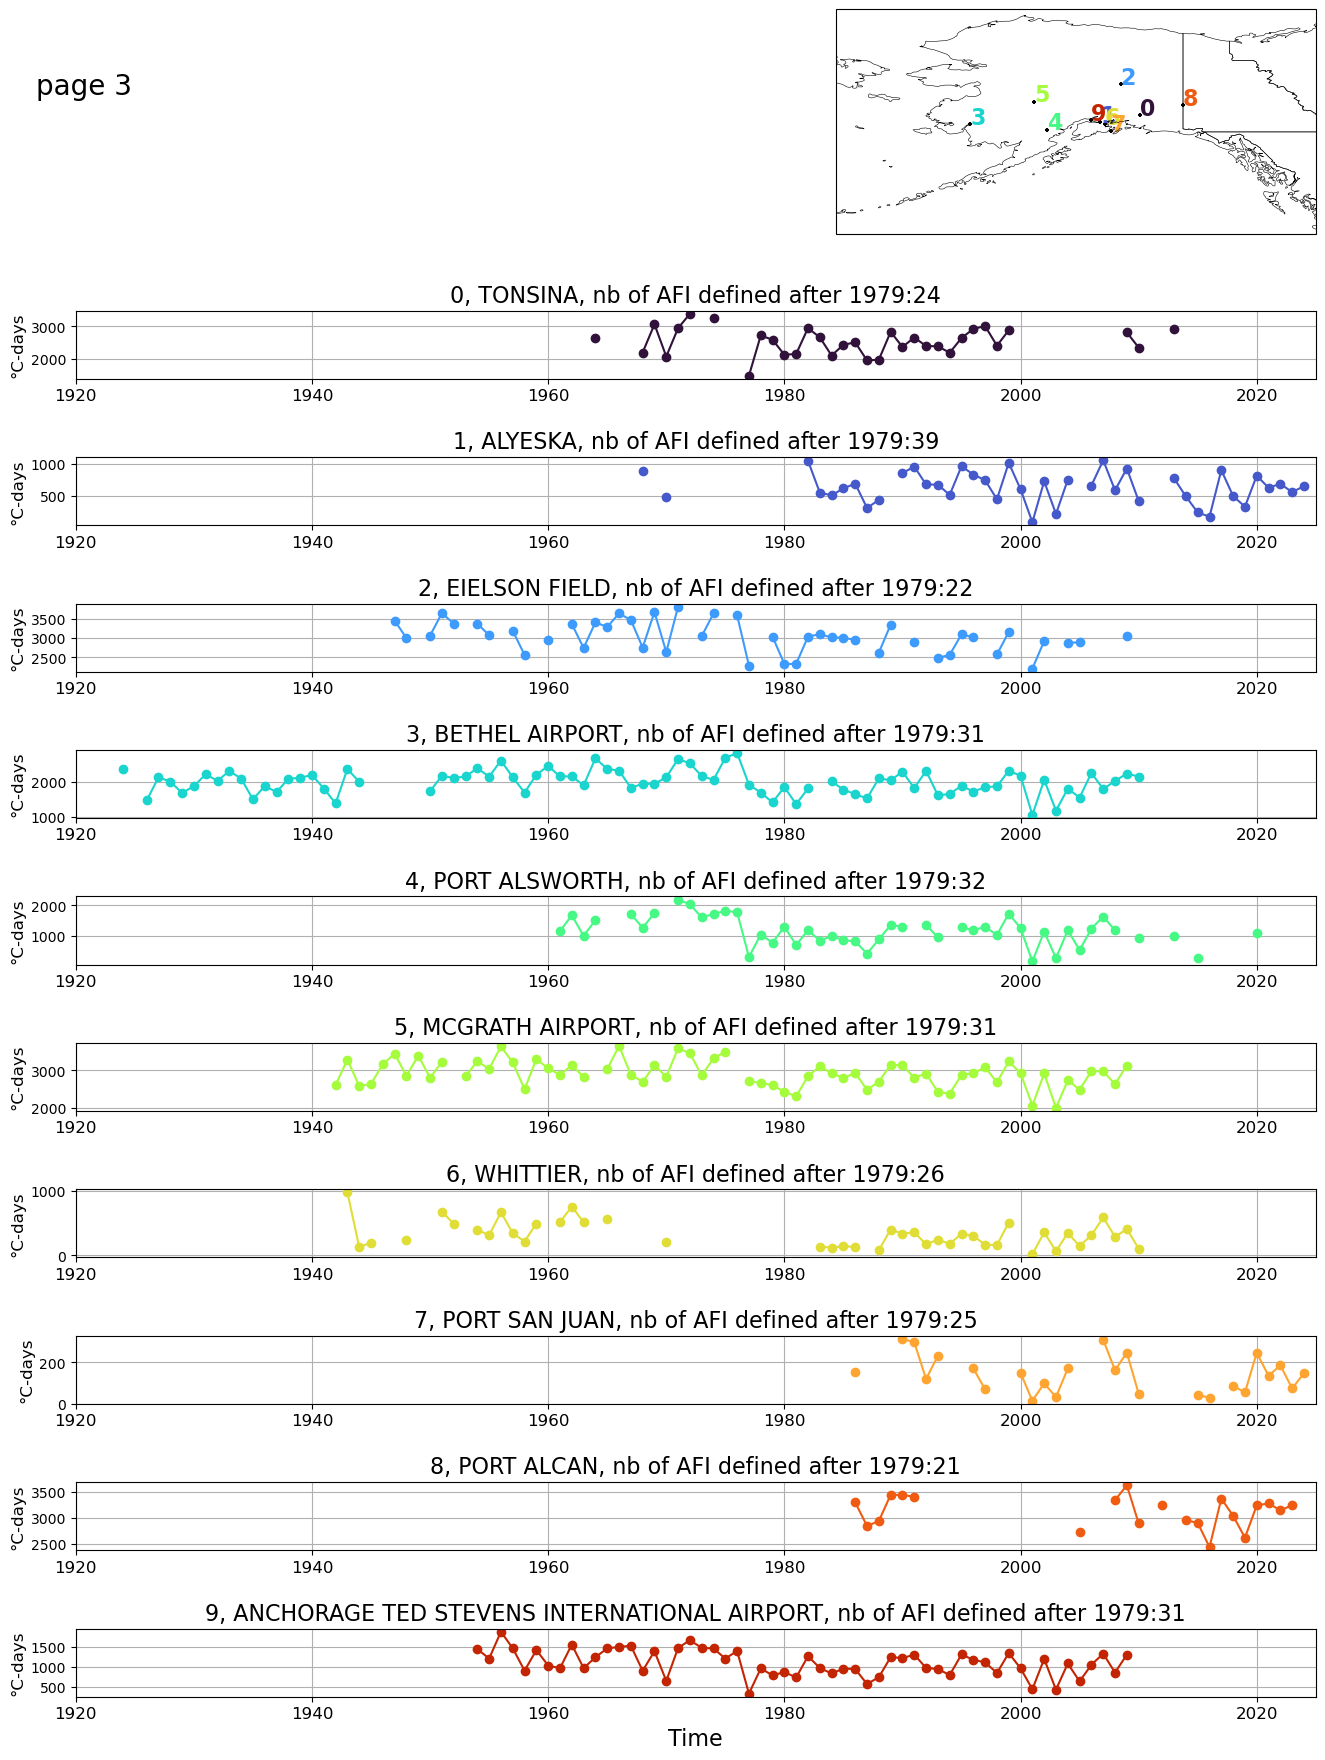

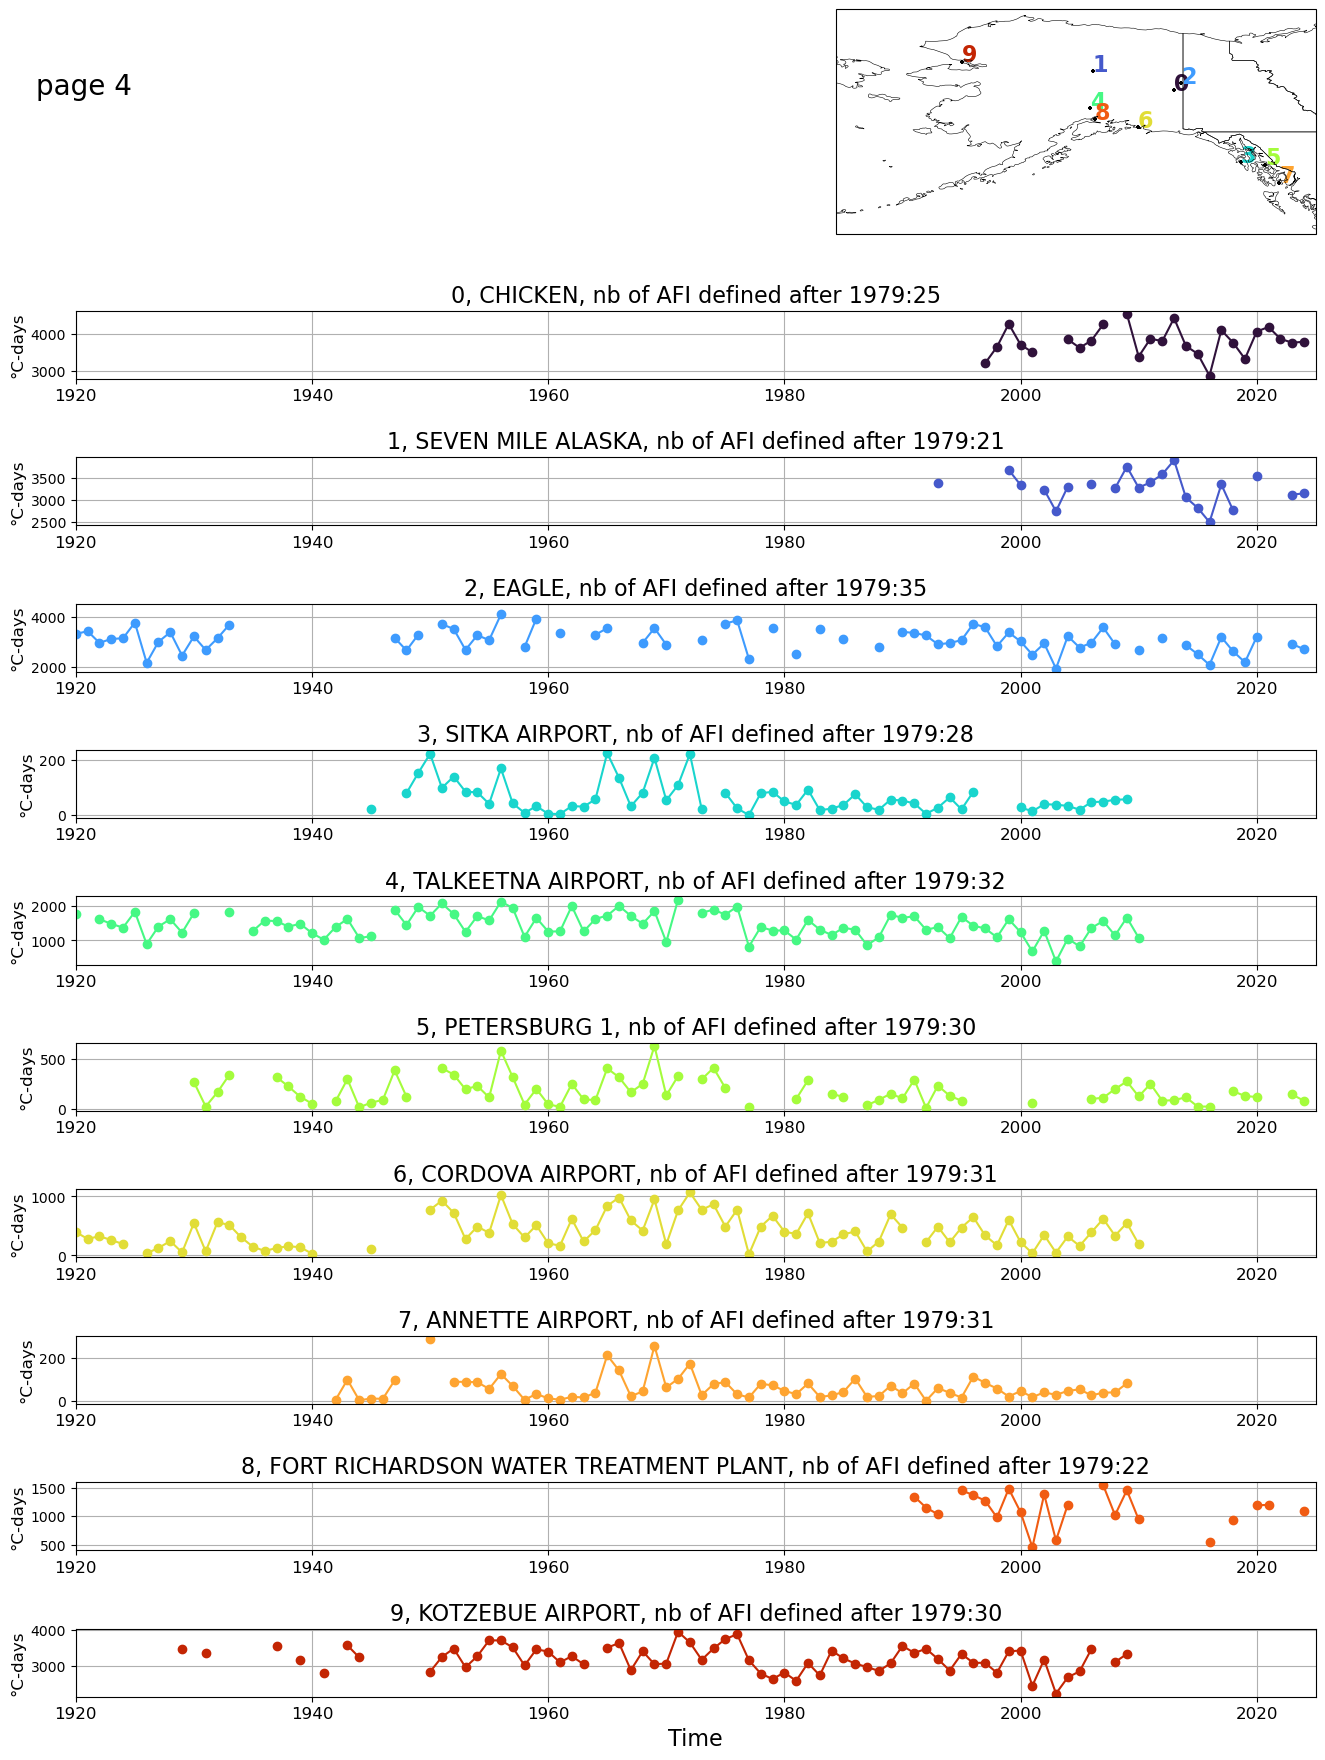

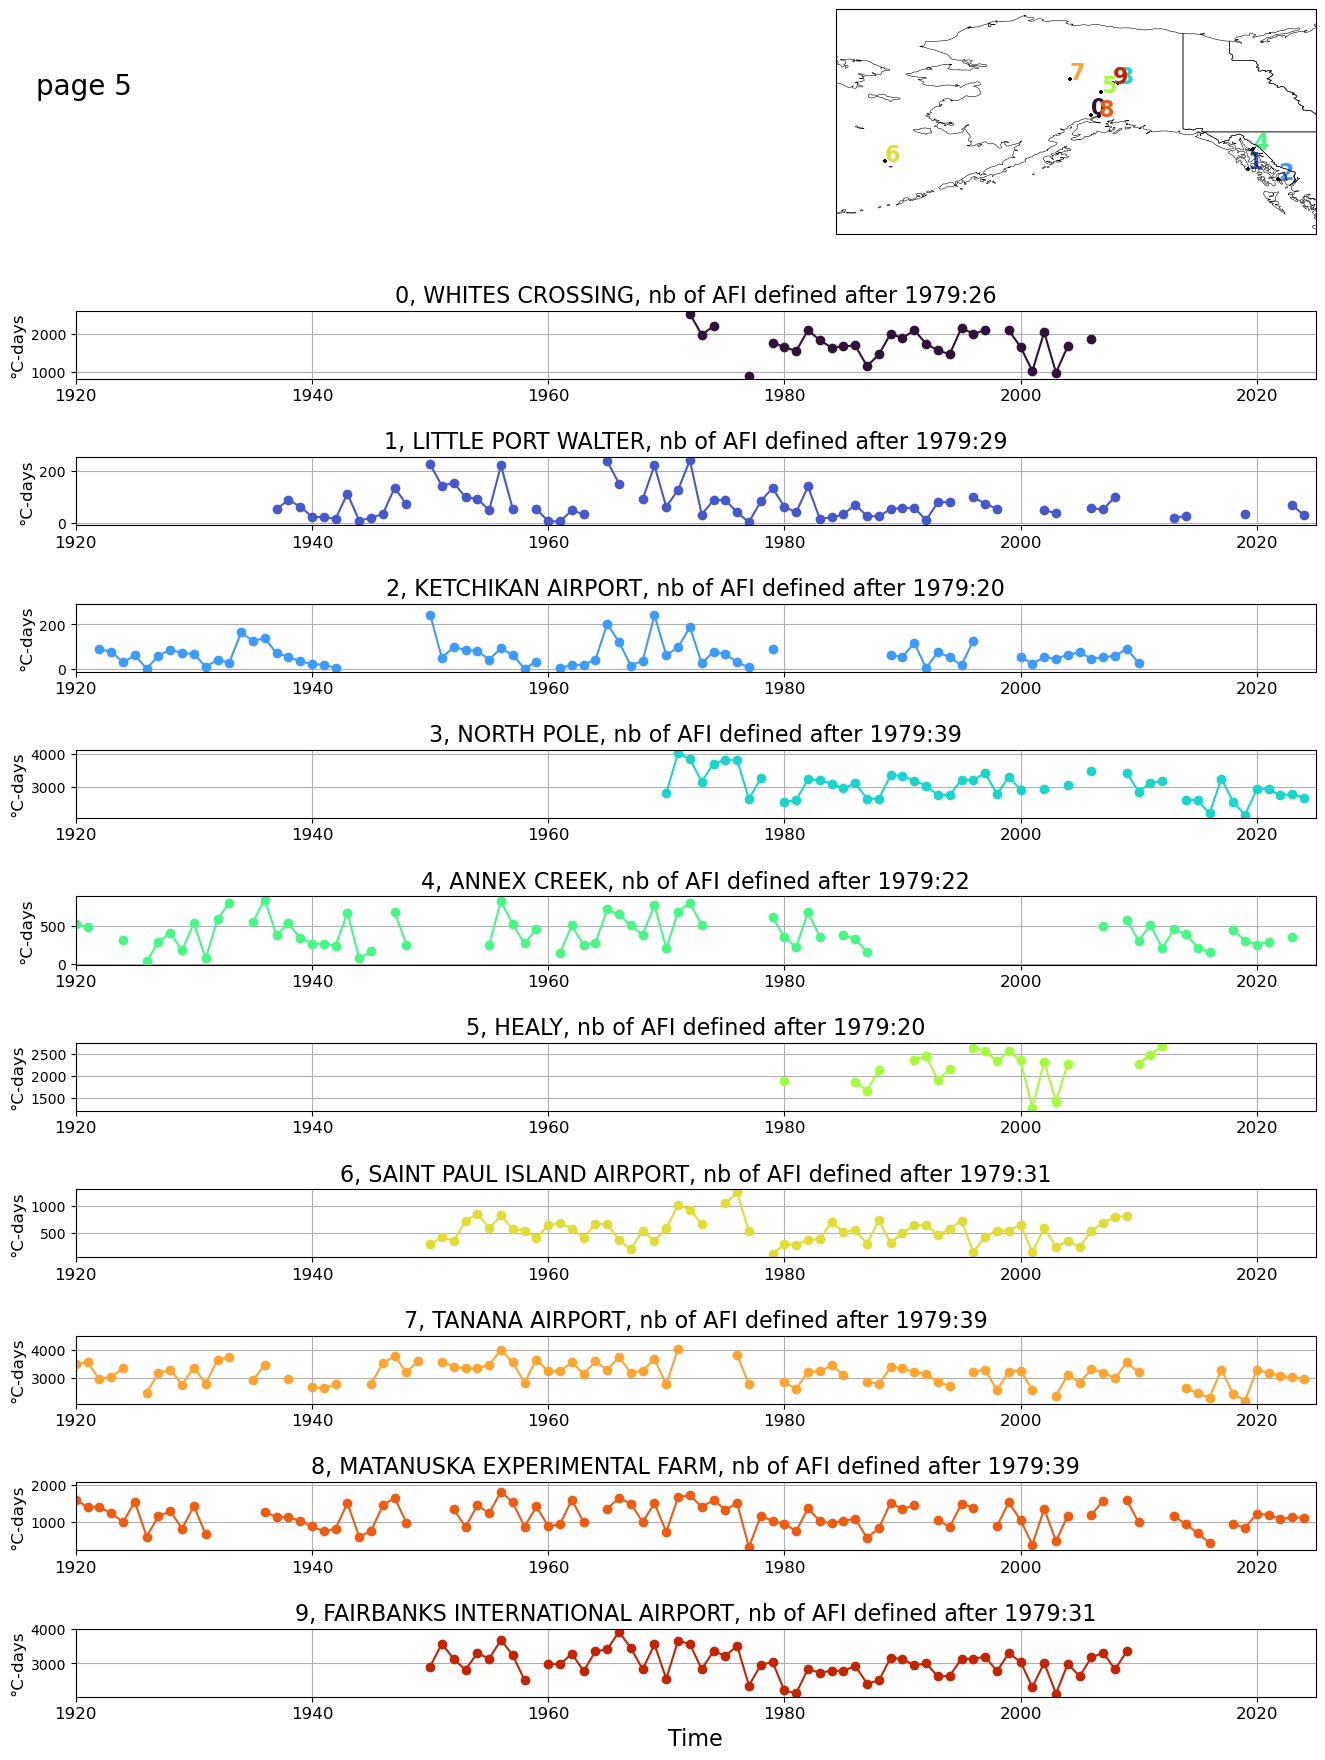

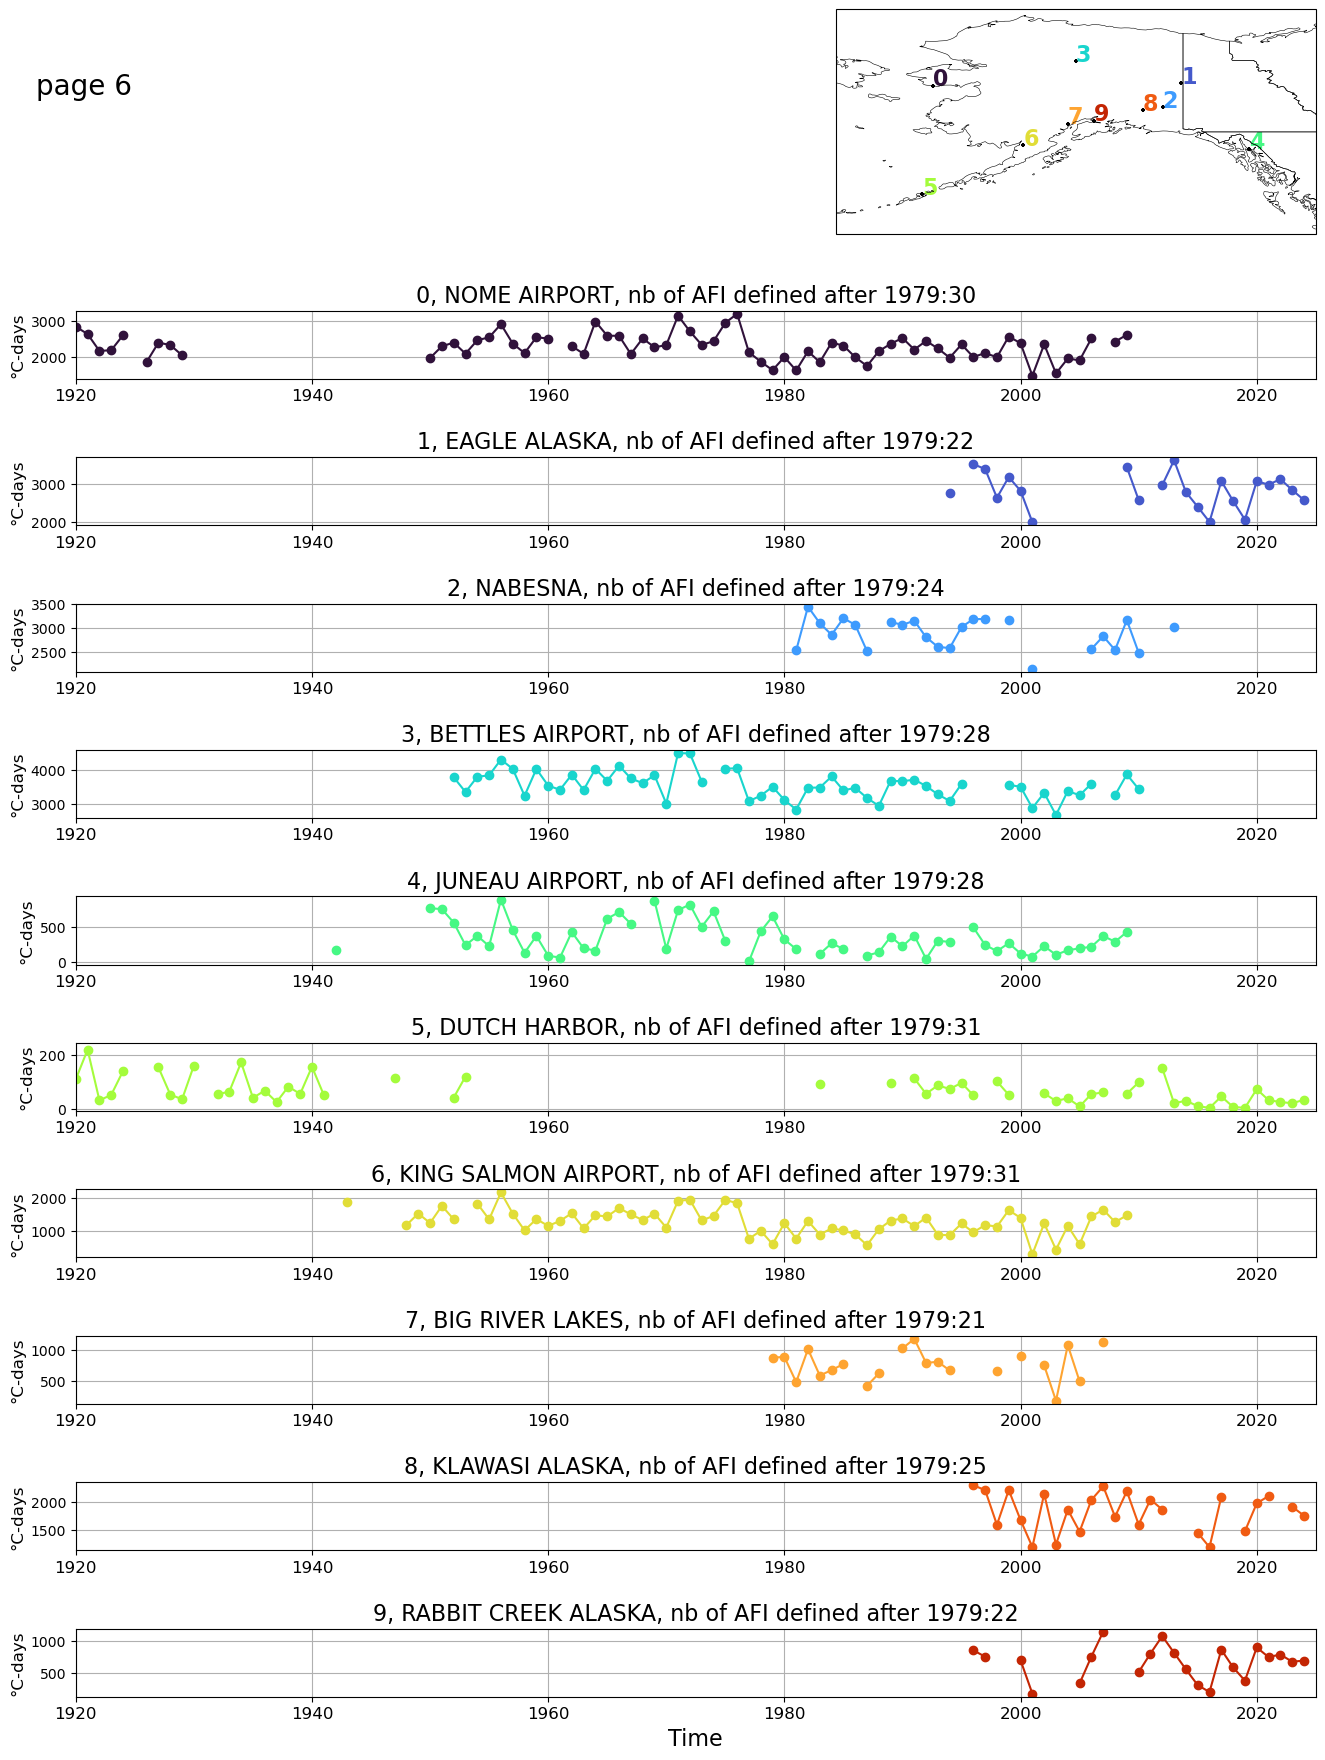

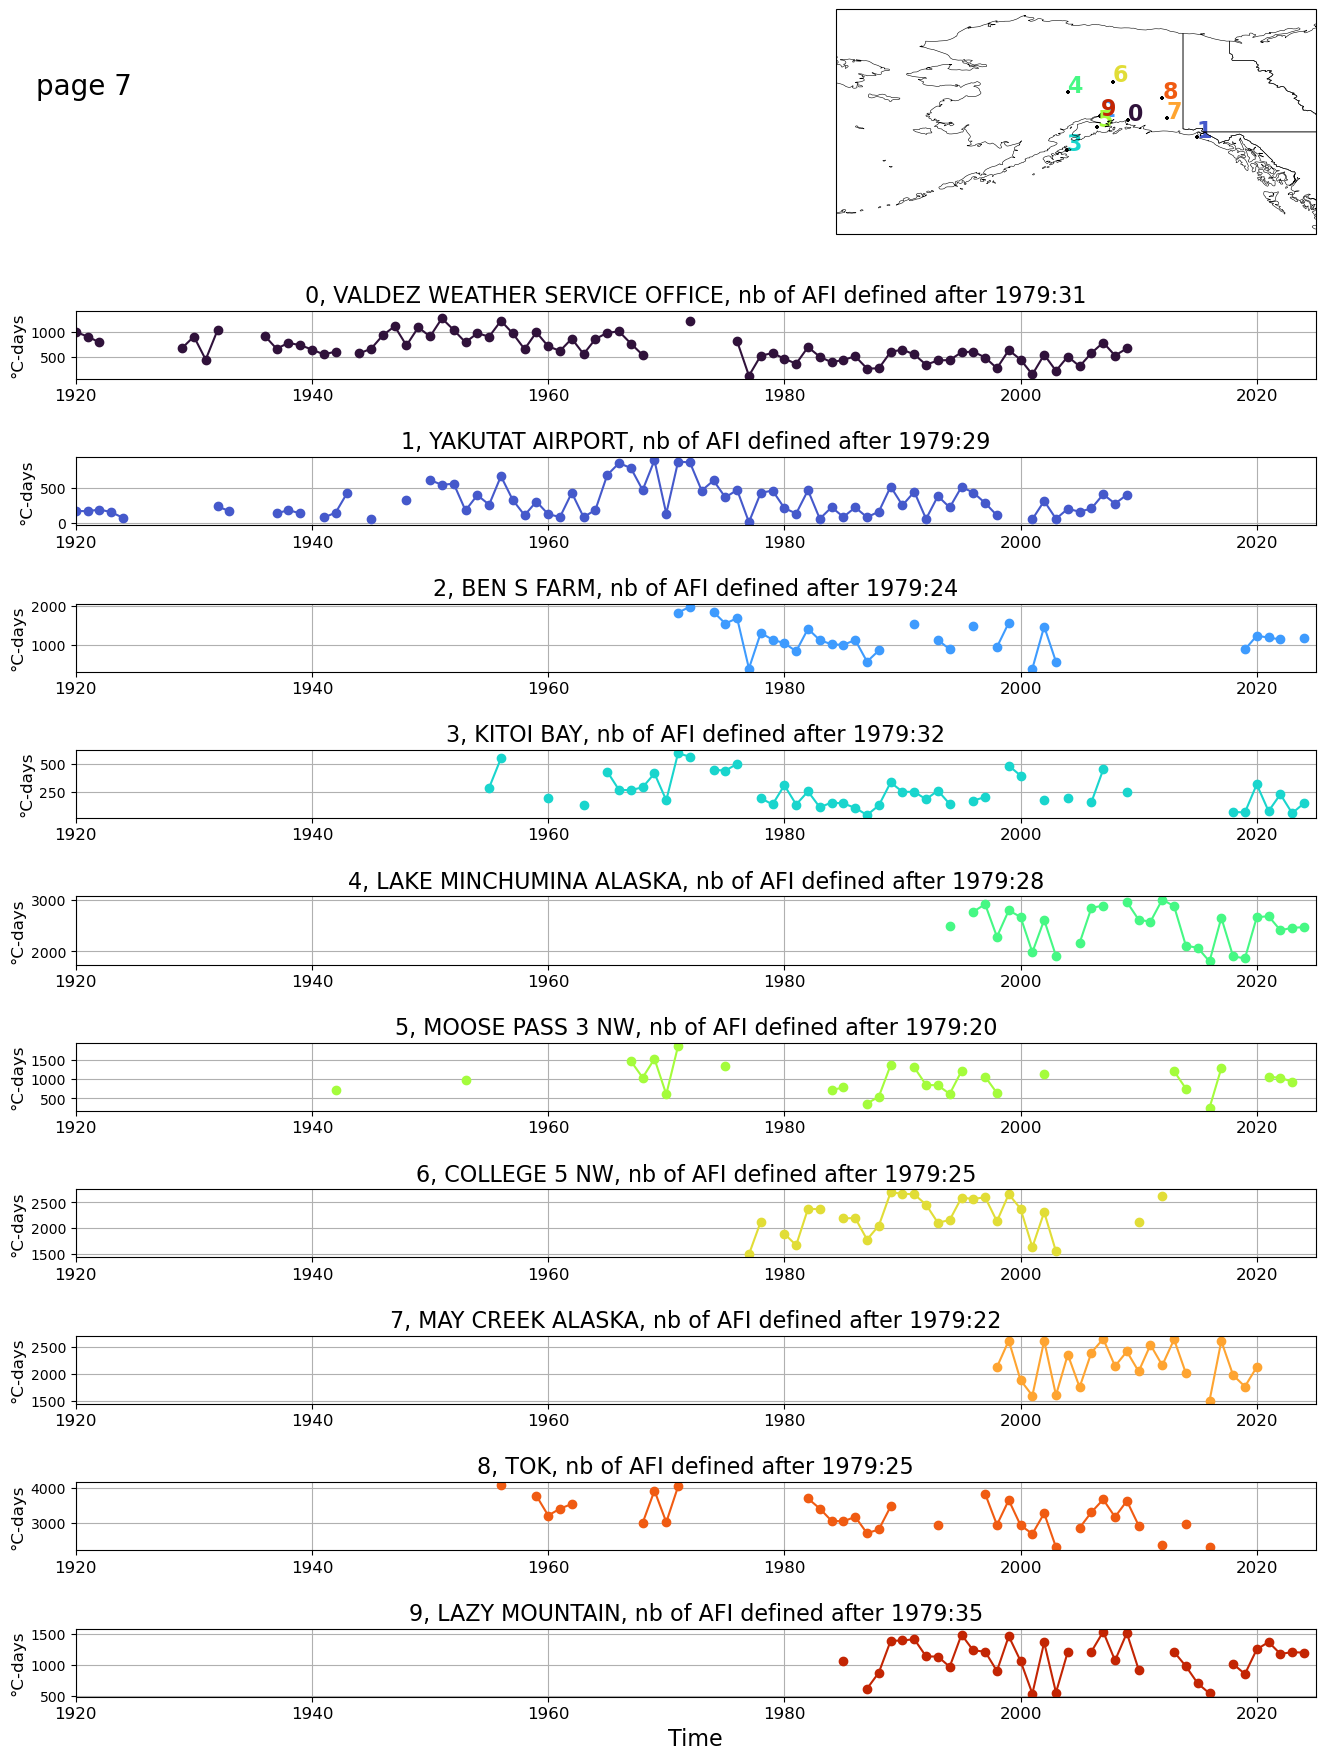

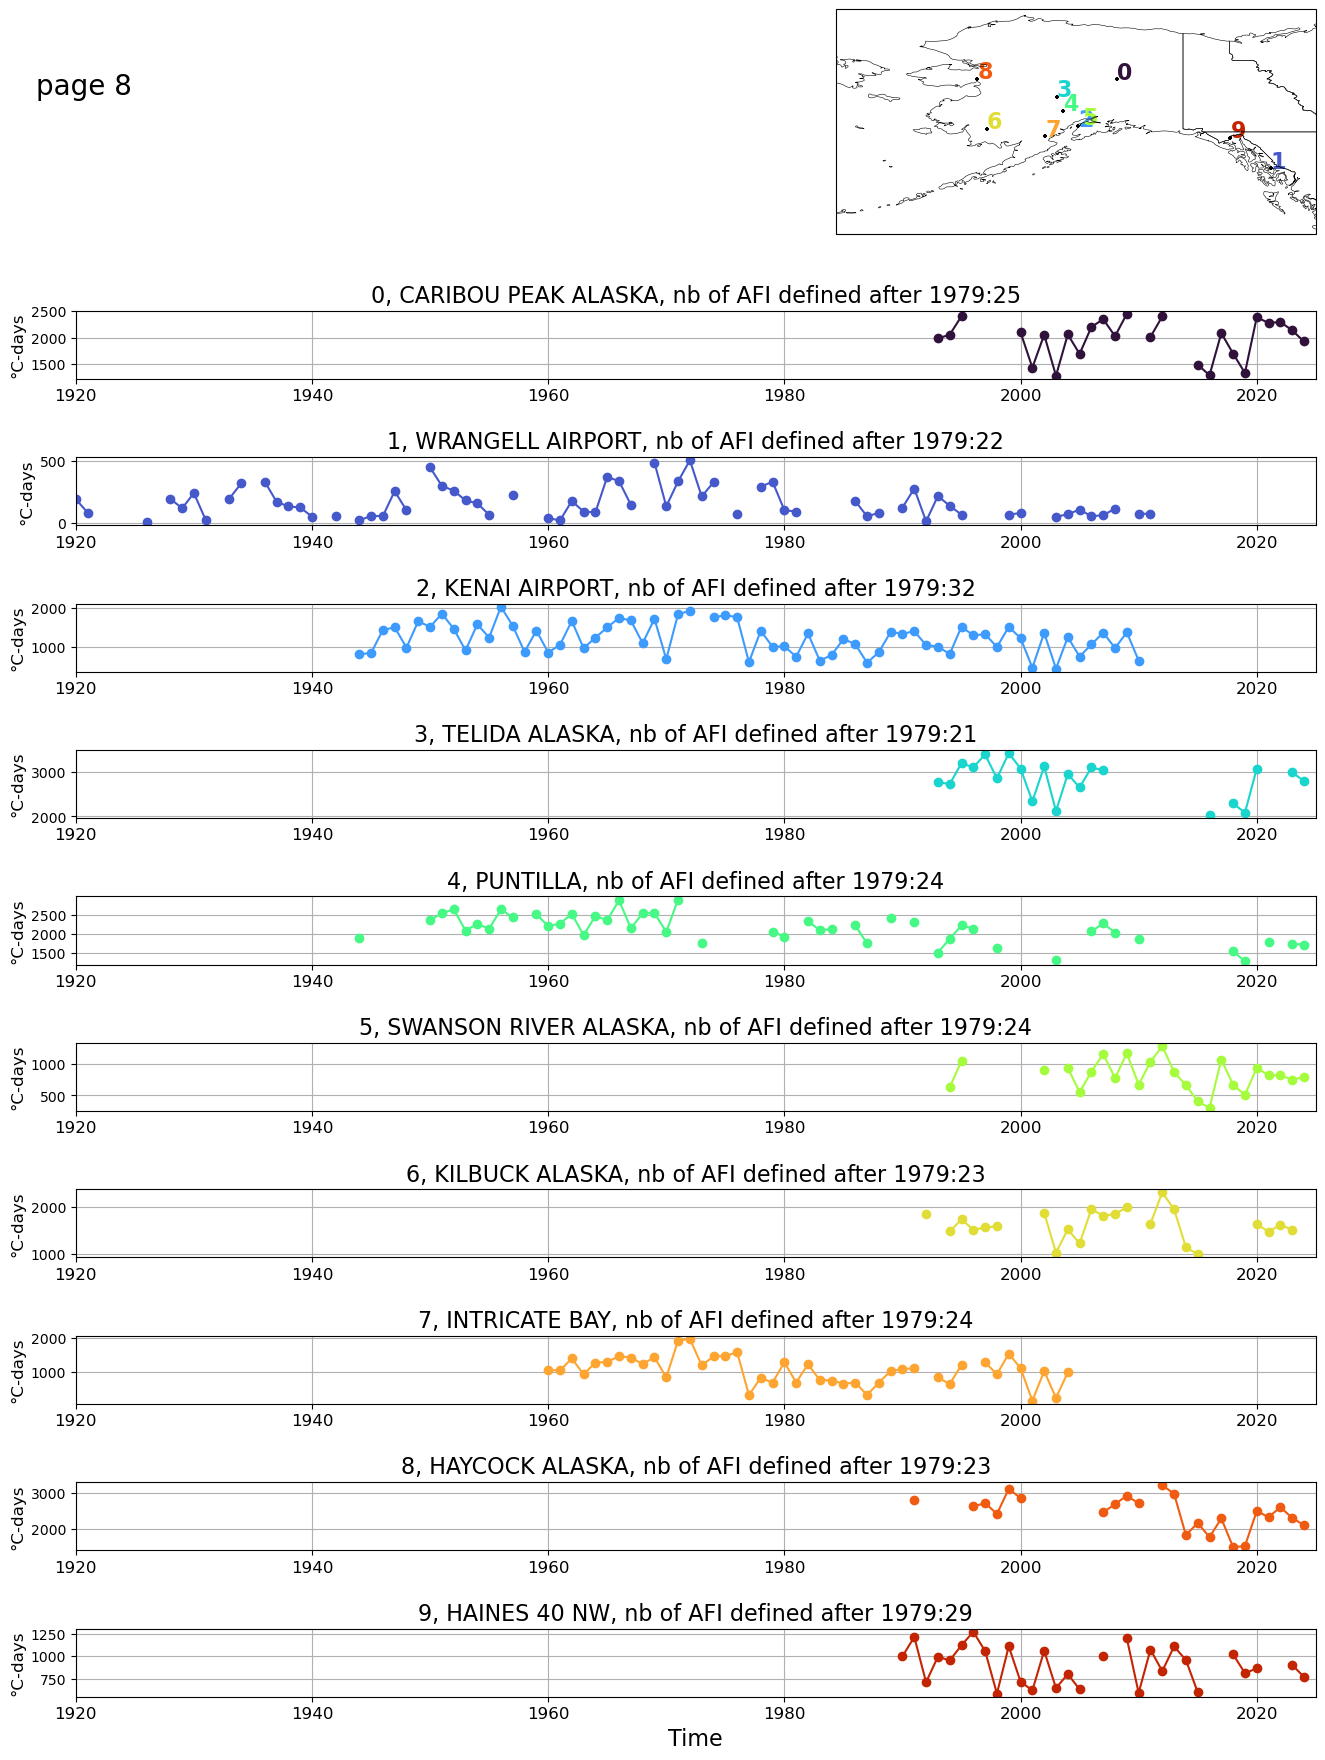

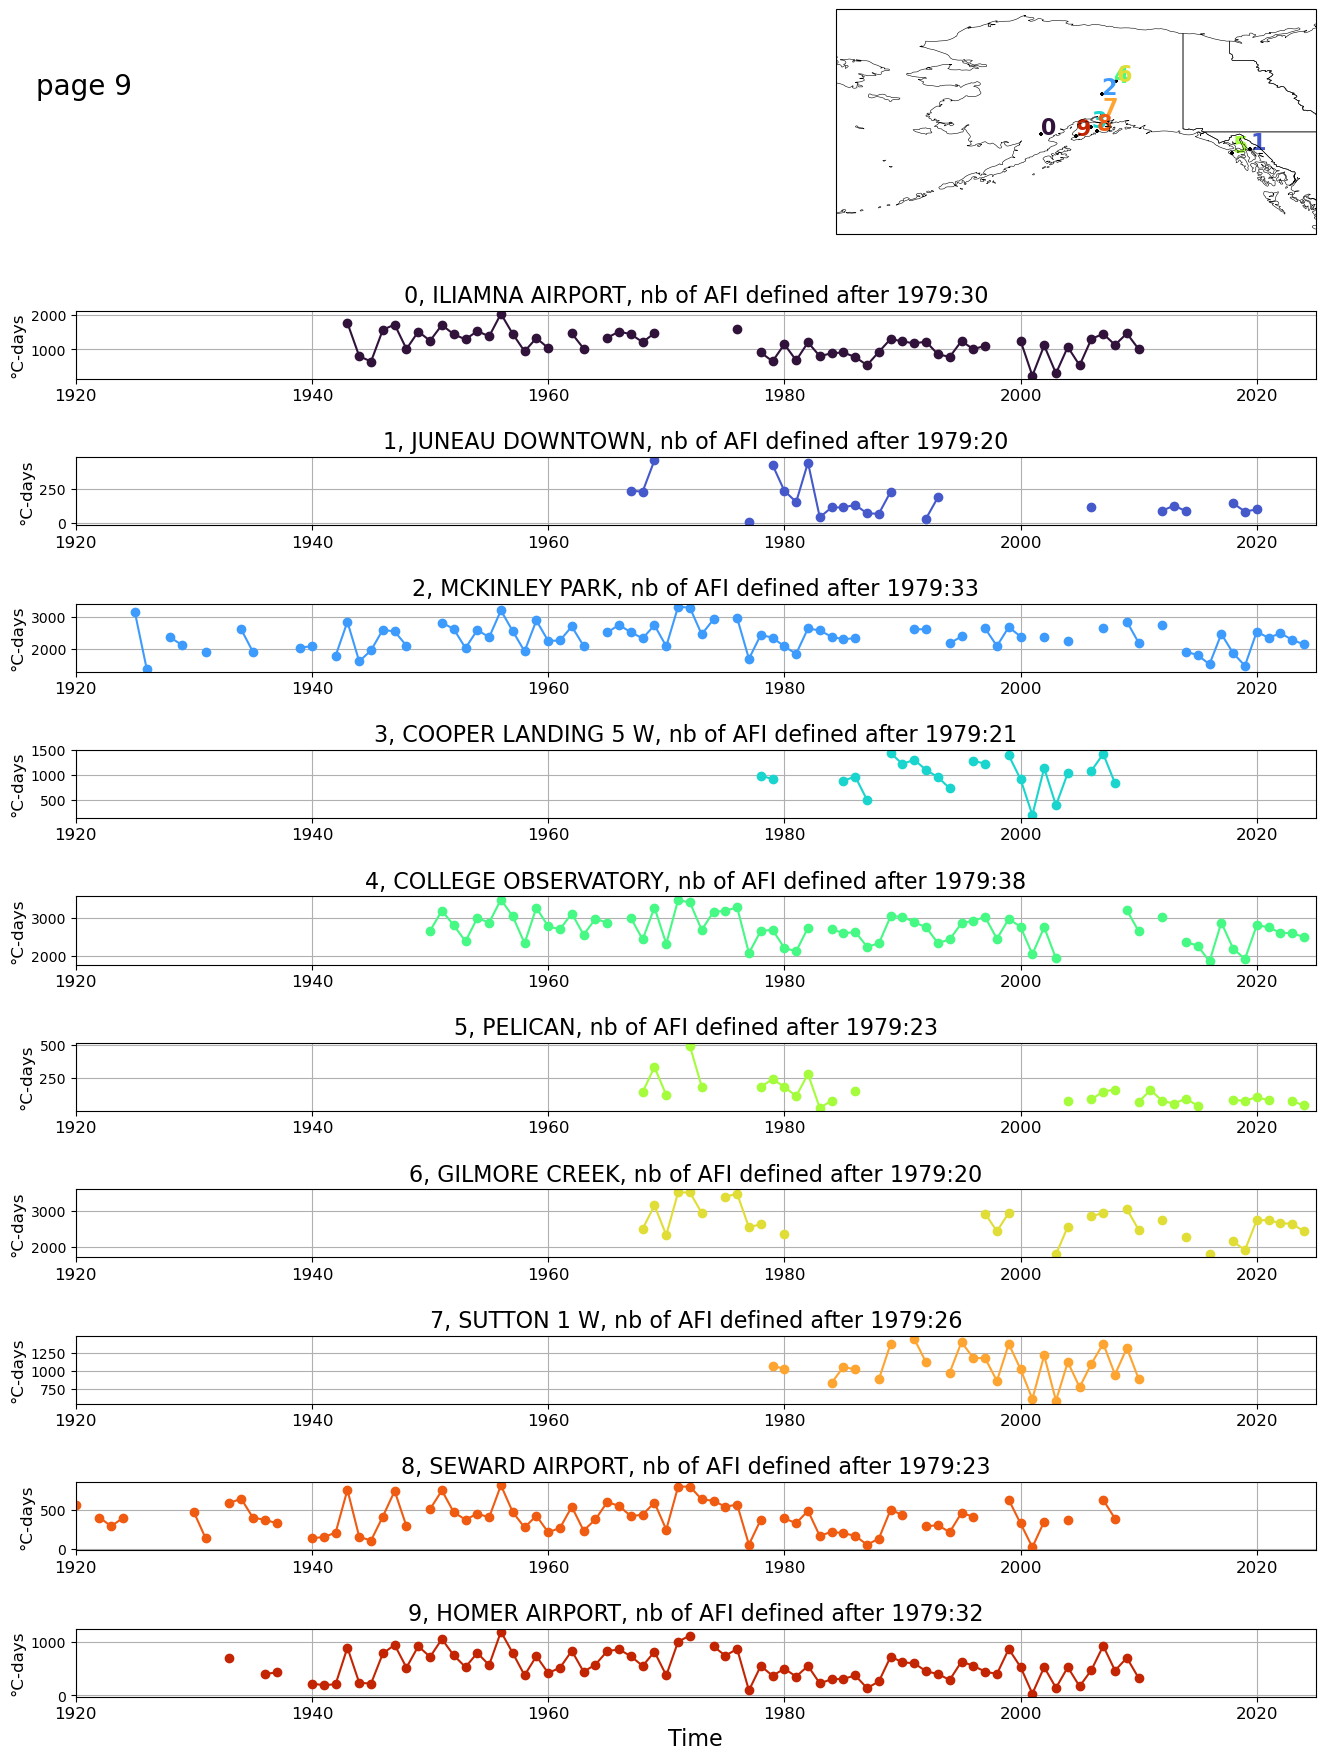

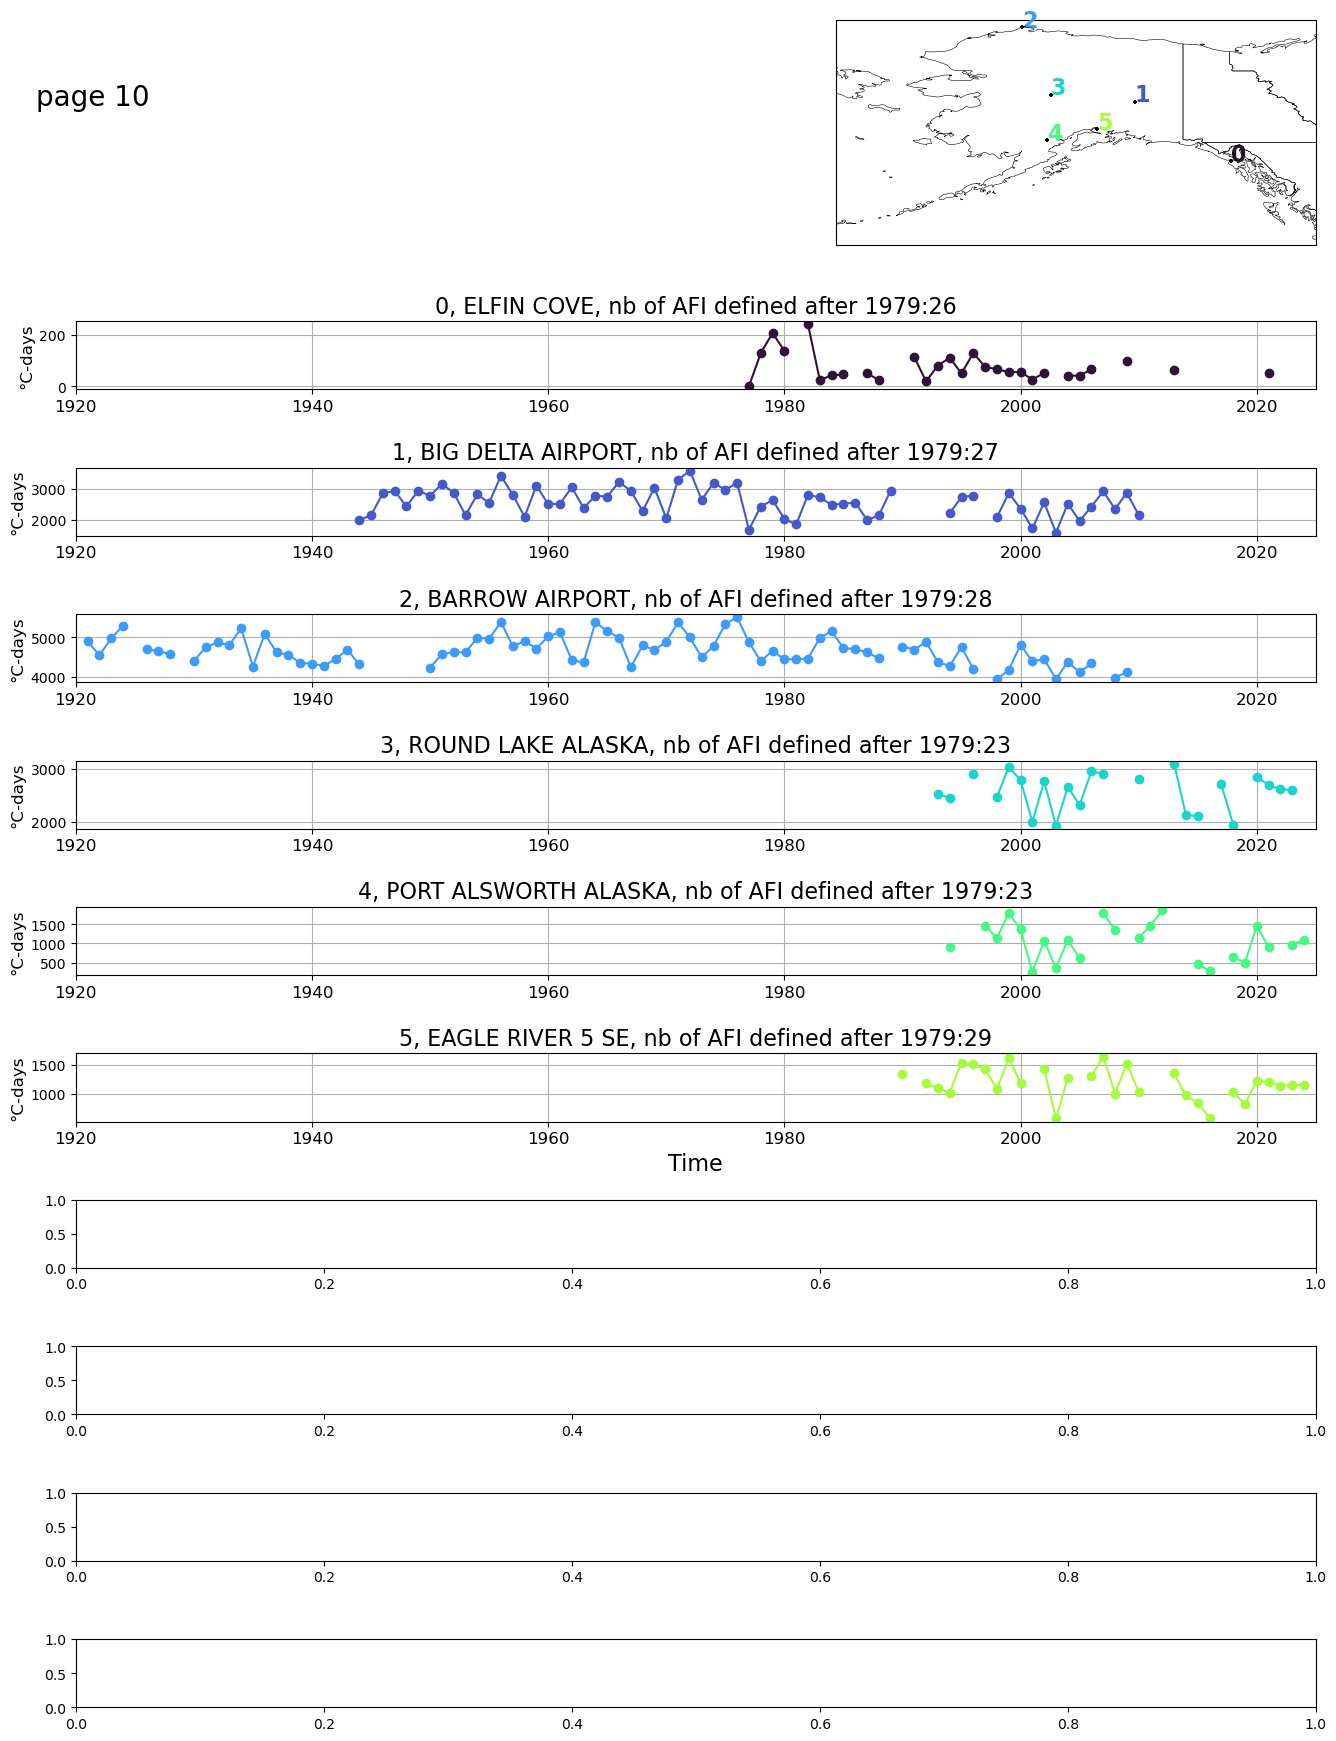

In [51]:
k=1
Tip20=np.where(nb79>=20)[0]
for ii in range(0,len(Tip20),10):
  fig, ax = plt.subplots(nrows=10,ncols=1,figsize=(16,18))
  colors=cm.get_cmap('turbo',11)
  fig.subplots_adjust(hspace=1.15)
  ax_inset = fig.add_axes([0.6, 0.86, 0.3, 0.25], projection=ccrs.PlateCarree())
  ax_inset.set_extent([lon_min,lon_max,lat_min,lat_max],proj)
  ax_inset.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  for pp in range(ii,ii+10):
    if pp< len(Tip20):
      ip = Tip20[pp]
      ix=pp-ii
      istation = nb79.station[ip].data.item() 
      iname = names[ip]
      if longitudes[ip]+360<=lon_max:
        ax_inset.scatter(longitudes[ip],latitudes[ip],marker='+',s=10,color='k')
        ax_inset.text(longitudes[ip],latitudes[ip],ix,color=colors(ix),fontsize=16,fontweight='bold')
      afi.sel(station=istation).plot(ax=ax[ix],color=colors(ix),marker='o')
      ax[ix].set_xlim(1920,2025)
      ax[ix].set_ylabel(f'{units}',fontsize=12)  
      ax[ix].set_xticklabels(ax[ix].get_xticklabels(),fontsize=12)  
      ax[ix].set_xlabel('',fontsize=16)
      ax[ix].grid()
      ax[ix].set_title(f'{ix}, {iname}, nb of AFI defined after 1979:{nb79.sel(station=istation).data.item():d}',fontsize=16)
  ax[ix].set_xlabel('Time',fontsize=16)
  fig.text(0.1,1,f'page {k}',fontsize=20)
  k = k+1
  plt.show()

---

## Figure Interpretation Guide

### Multi-Page Time Series Figures (Pages 1, 2, 3, ...)

**Figure Structure:**
Each page displays time series for 10 Alaska weather stations with the following components:

#### Main Time Series Panels (Left Side)

**Layout:**
- 10 stacked panels, one for each station
- Each panel shows the complete 1920–2025 AFI record for that station
- Colored markers (turbo colormap) distinguish stations on the page

**What to Look For:**

1. **Long-Term Trend**
   - Upward trend: Increasing freezing severity over time
   - Downward trend: Decreasing freezing severity (warming)
   - Flat: Stable freezing conditions

2. **Interannual Variability**
   - High-frequency oscillations represent year-to-year changes in freezing conditions
   - Cold years (high AFI peaks) and mild years (low AFI valleys)

3. **Data Quality Indicators**
   - **Gaps**: Missing years indicate insufficient data (not meeting 75% day-count quality threshold)
   - **Continuous sequences**: Periods with no gaps show high-quality, complete data
   - **Title information**: "nb of AFI defined after 1979" shows the count of valid years post-1979

4. **Extreme Events**
   - **Peaks**: Severe freezing winters (high °C-days)
   - **Troughs**: Mild winters (low °C-days)
   - **Plateaus**: Multi-year periods of similar freezing intensity

#### Inset Map (Upper Right)

**Purpose:**
Shows the geographic location of the 10 stations on this page within Alaska.

**Elements:**
- **State borders**: Gray lines showing Alaska and neighboring regions
- **Station markers**: Plus symbols (+) mark exact station locations
- **Index labels**: Colored numbers (0–9) correspond to the main panels below
- **Domain box**: Indicates the full analysis area (50°N–72°N, 185°E–232°E)

**Spatial Interpretation:**
- **Western stations** (left/lower longitude): Might show different AFI patterns than eastern stations
- **Southern stations** (lower latitude): Generally warmer, potentially lower AFI
- **Arctic stations** (higher latitude): Typically more severe freezing, higher AFI

#### Cross-Page Analysis

**Comparing Multiple Pages:**
- Early pages show western Alaska stations
- Later pages show central and eastern Alaska stations
- Look for systematic differences in AFI magnitude and variability across Alaska's east-west span

**Key Questions for Each Station:**

1. **Severity**: How do AFI values compare across stations? Which regions experience most severe freezing?

2. **Trends**: Is there a consistent warming or cooling trend, or has freezing severity remained stable?

3. **Variability**: Which stations show high interannual variability vs. stable conditions?

4. **Outliers**: Are there particularly extreme years visible in the record?

5. **Data Availability**: Which stations have the longest, most complete records?

### Applications

**Engineering and Design:**
- **100-year return level**: Can be estimated from long records for infrastructure design (ASCE 32-01)
- **Frost depth calculations**: AFI values directly inform permafrost and foundation design standards

**Climate Monitoring:**
- **Trend detection**: Changes in AFI over decades indicate regional climate warming or cooling
- **Decadal variability**: Multi-year cycles in AFI may reflect ocean-atmosphere oscillations

**Agricultural Planning:**
- **Crop selection**: Understanding regional AFI severity guides crop feasibility
- **Frost protection**: AFI records inform timing and extent of frost damage risk